In [12]:
import os

os.environ["OMP_NUM_THREADS"] = "16"
os.environ["MKL_NUM_THREADS"] = "16"
os.environ["OPENBLAS_NUM_THREADS"] = "16"
os.environ["BLIS_NUM_THREADS"] = "16"
os.environ["VECLIB_MAXIMUM_THREADS"] = "16"
os.environ["NUMEXPR_NUM_THREADS"] = "16"

# 1. Installation, imports et loadings

In [13]:
import os
import glob
import json
from pathlib import Path

!pip install duckdb --quiet
!pip install numpy --quiet
!pip install matplotlib --quiet
!pip install seaborn --quiet
!pip install jinja2 --quiet
!pip install spicy --quiet


import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy.stats import pearsonr

import matplotlib.dates as mdates
!pip install plotly --quiet
!pip install --upgrade nbformat
import plotly.express as px
                                
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

                               
DATA_DIR = Path("/data/gdelt/gdelt_parquet_db")
SOURCE_MAP_PATH = Path("/data/gdelt/gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f" {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")

                                          
con = duckdb.connect()
con.execute("PRAGMA memory_limit='200GB'")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")

                                            
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print(" Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB")


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
 137 fichiers parquet trouvés (414.49 Go).
 Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB


In [14]:
con.execute("SET threads TO 16")

# 2. Nettoyage de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.
## 2.1. Broken ID and no source 

In [15]:
con.execute(r"""
    CREATE OR REPLACE VIEW gkg_clean AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

                    
# bilan_nettoyage = con.execute("""
#     SELECT 
#         '1. GKG Brut' AS Etape, COUNT(*) AS Lignes_Totales 
#     FROM gkg
#     UNION ALL
#     SELECT 
#         '2. GKG Clean', COUNT(*) 
#     FROM gkg_clean
# """).df()

# bilan_nettoyage['Lignes_Supprimees'] = bilan_nettoyage['Lignes_Totales'].iloc[0] - bilan_nettoyage['Lignes_Totales']
# display(bilan_nettoyage.style.format({'Lignes_Totales': '{:,}', 'Lignes_Supprimees': '{:,}'}).hide(axis="index"))

## 2.2 No theme-less

In [16]:
con.execute(r"""
    CREATE OR REPLACE VIEW gkg_themes AS
    
    SELECT *
    FROM gkg_clean
    WHERE EnhancedThemes IS NOT NULL 
      AND EnhancedThemes != ''
""")

# Bilan rapide de la création
# bilan_themes = con.execute("""
#     SELECT 
#         '1. GKG Clean' AS Etape, COUNT(*) AS Lignes 
#     FROM gkg_clean
#     UNION ALL
#     SELECT 
#         '2. GKG Themes (Filtre appliqué)', COUNT(*) 
#     FROM gkg_themes
# """).df()

# bilan_themes['Supprimées'] = bilan_themes['Lignes'].iloc[0] - bilan_themes['Lignes']
# display(bilan_themes.style.format({'Lignes': '{:,}', 'Supprimées': '{:,}'}).hide(axis="index"))
# print("Vue 'gkg_themes' créée avec succès.")

## 2.3 Words outliers

In [17]:
MIN_WORDS = 15     # Exclut les brèves, les flux RSS et les erreurs (ex: 50 mots)
MAX_WORDS = 6500   # Exclut les rapports géants et les pages web entières mal découpées (ex: 4000 mots)

query_words = f"""
    CREATE OR REPLACE VIEW gkg_words AS
    
    SELECT *
    FROM gkg_themes
    WHERE WordCount BETWEEN {MIN_WORDS} AND {MAX_WORDS}
"""
con.execute(query_words)

# bilan_words = con.execute(f"""
#     SELECT 
#         '1. GKG Themes' AS Etape, COUNT(*) AS Lignes 
#     FROM gkg_themes
#     UNION ALL
#     SELECT 
#         '2. GKG Words ({MIN_WORDS} à {MAX_WORDS} mots)', COUNT(*) 
#     FROM gkg_words
# """).df()

# bilan_words['Supprimées'] = bilan_words['Lignes'].iloc[0] - bilan_words['Lignes']
# display(bilan_words.style.format({'Lignes': '{:,}', 'Supprimées': '{:,}'}).hide(axis="index"))

## 2.4 Amount of articles per source

In [18]:
MIN_ARTICLES_PER_SOURCE = 30

query_sources_view = f"""
    CREATE OR REPLACE VIEW gkg_sources AS
    
    WITH ValidSources AS (
        -- 1. On identifie les sources qui atteignent le seuil
        SELECT SourceCommonName_ID
        FROM gkg_words
        WHERE SourceCommonName_ID IS NOT NULL
        GROUP BY SourceCommonName_ID
        HAVING COUNT(*) >= {MIN_ARTICLES_PER_SOURCE}
    )
    -- 2. On filtre la base complète en ne gardant que ces sources
    SELECT w.*
    FROM gkg_words w
    INNER JOIN ValidSources v 
      ON w.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_sources_view)

# Bilan du filtrage
# bilan_sources = con.execute(f"""
#     WITH stats_words AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_words
#     ),
#     stats_sources AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_sources
#     )
#     SELECT 
#         '1. GKG Words' AS Etape, 
#         w.lignes AS "Nombre d'articles", 
#         w.sources AS "Sources distinctes"
#     FROM stats_words w
#     UNION ALL
#     SELECT 
#         '2. GKG Sources (>= {MIN_ARTICLES_PER_SOURCE} articles)', 
#         s.lignes, 
#         s.sources
#     FROM stats_sources s
# """).df()

# # Calcul des suppressions
# articles_suppr = bilan_sources["Nombre d'articles"].iloc[0] - bilan_sources["Nombre d'articles"].iloc[1]
# sources_suppr = bilan_sources["Sources distinctes"].iloc[0] - bilan_sources["Sources distinctes"].iloc[1]

# print(f"✅ Vue créée. Bilan du nettoyage :")
# print(f"- Articles supprimés : {articles_suppr:,}")
# print(f"- Sources fantômes/micro-éditeurs éliminés : {sources_suppr:,}")

# display(bilan_sources.style.format({"Nombre d'articles": '{:,}', "Sources distinctes": '{:,}'}).hide(axis="index"))

## 2.5 Years of activity per source

In [19]:
MIN_ACTIVE_YEARS = 2

query_year_view = f"""
    CREATE OR REPLACE VIEW gkg_year AS
    
    WITH ValidSources AS (
        -- On identifie les sources qui ont publié sur au moins X années distinctes
        SELECT SourceCommonName_ID
        FROM gkg_sources
        GROUP BY SourceCommonName_ID
        HAVING COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) >= {MIN_ACTIVE_YEARS}
    )
    -- On filtre en faisant une jointure interne
    SELECT s.*
    FROM gkg_sources s
    INNER JOIN ValidSources v 
      ON s.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_year_view)

# Bilan du filtrage
# bilan_year = con.execute(f"""
#     WITH stats_sources AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_sources
#     ),
#     stats_year AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_year
#     )
#     SELECT 
#         '1. GKG Sources' AS Etape, 
#         s.lignes AS "Nombre d'articles", 
#         s.sources AS "Sources distinctes"
#     FROM stats_sources s
#     UNION ALL
#     SELECT 
#         '2. GKG Year (>= {MIN_ACTIVE_YEARS} ans)', 
#         y.lignes, 
#         y.sources
#     FROM stats_year y
# """).df()

# # Calcul du nettoyage
# articles_suppr = bilan_year["Nombre d'articles"].iloc[0] - bilan_year["Nombre d'articles"].iloc[1]
# sources_suppr = bilan_year["Sources distinctes"].iloc[0] - bilan_year["Sources distinctes"].iloc[1]

# print(f"✅ Vue 'gkg_year' créée. Bilan de l'écrémage éditorial :")
# print(f"- Articles retirés : {articles_suppr:,}")
# print(f"- Sources éphémères éliminées : {sources_suppr:,}")

# display(bilan_year.style.format({"Nombre d'articles": '{:,}', "Sources distinctes": '{:,}'}).hide(axis="index"))

## 2.6 Themes per source

In [20]:
MIN_THEMES = 2

query_final_view = f"""
    CREATE OR REPLACE VIEW gkg_final AS
    
    SELECT *
    FROM gkg_year
    WHERE CASE 
            WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 0
            ELSE ARRAY_LENGTH(string_split(EnhancedThemes, ';'))
          END >= {MIN_THEMES}
"""

con.execute(query_final_view)

## 2.7 1% of the database
We will only work with 1% of the database.

In [22]:
gkg_final_1pc = con.execute("""
    SELECT *
    FROM gkg_final
    WHERE hash(GKGRECORDID) % 100 = 0
""").df()

# 3. Impact of the main sources

We want to make sure that the top sources don't bias the results in terms of themes frequently mentioned, theme variety and tone.

In [ ]:
n = 3 # top n sources

con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_sample AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

con.execute("""
    CREATE OR REPLACE TABLE minus_top_n_sources_sample AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final_1pc g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    OFFSET ?
""",[n] )

In [ ]:
top_n_sources_sample = con.execute("SELECT * FROM top_n_sources_sample").df()

display(top_n_sources_sample.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Source_ID,Articles
iheart.com,82787,"221,403"
yahoo.com,81,"99,037"
zazoom.it,36148,"95,418"


## 3.1 Impact on the themes mentioned

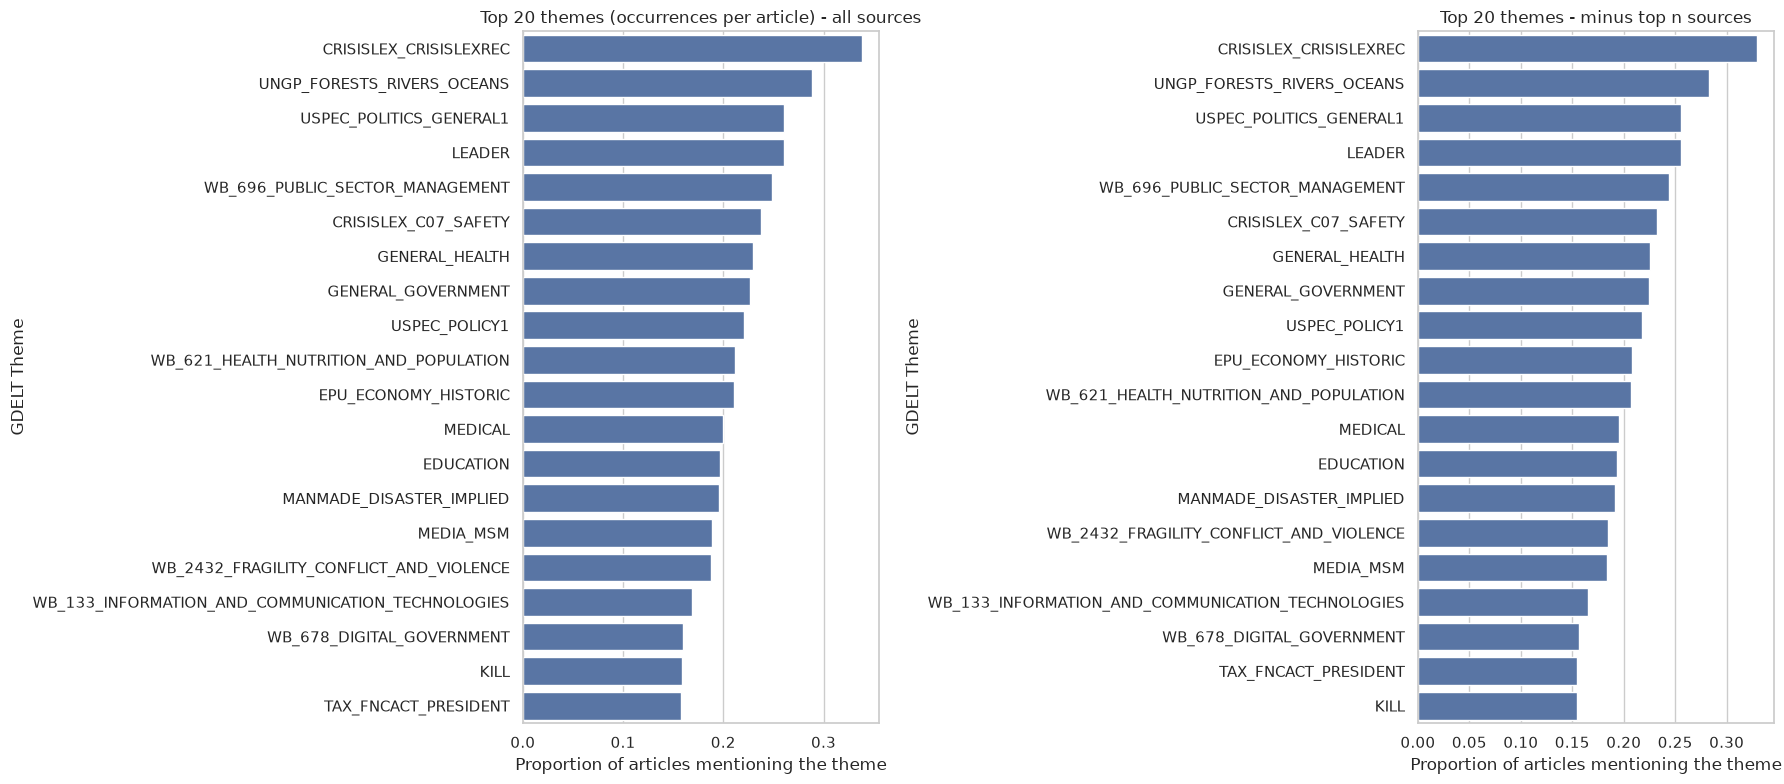

In [ ]:
top_themes = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_minus_top_n = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc g
            JOIN minus_top_n_sources_sample m
                ON g.SourceCommonName_ID = m.Source_ID
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=top_themes, x="proportion", y="theme", ax=axes[0])
axes[0].set_title('Top 20 themes (occurrences per article) - all sources')
axes[0].set_xlabel('Proportion of articles mentioning the theme')
axes[0].set_ylabel('GDELT Theme')
 

sns.barplot(data=top_themes_minus_top_n, x="proportion", y="theme", ax=axes[1])
axes[1].set_title('Top 20 themes - minus top n sources')
axes[1].set_xlabel('Proportion of articles mentioning the theme')
axes[1].set_ylabel('GDELT Theme')

plt.tight_layout()
plt.show()

The 2 charts are extremely similar, which means that the top sources don't bias the results.

## 3.2 Impact on the variety of themes

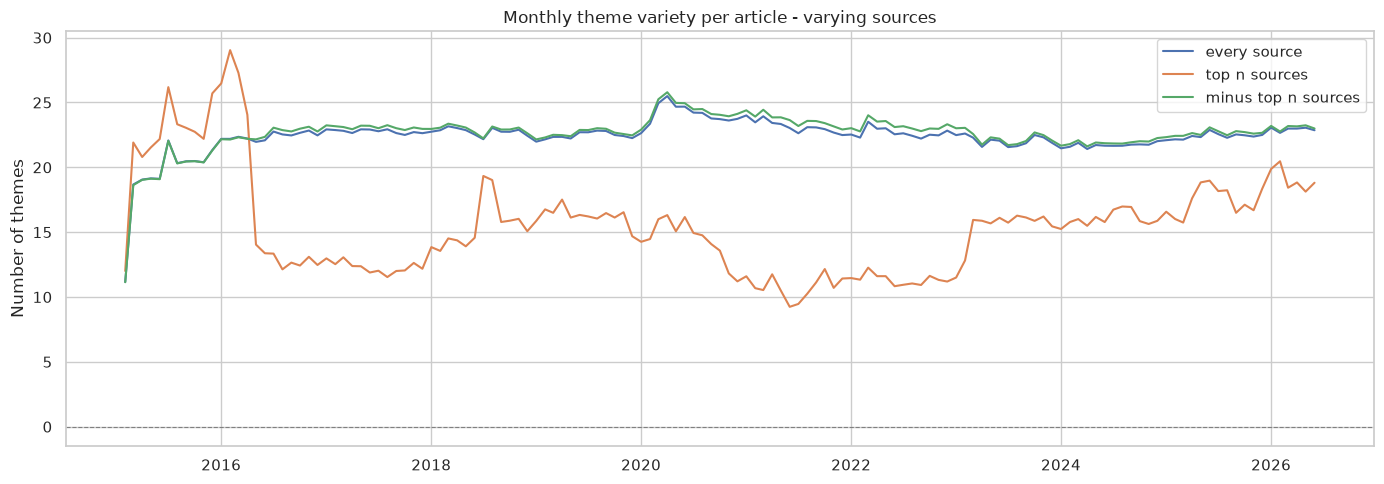

In [ ]:
theme_variety_per_article = con.execute("""
    WITH article_themes AS (
        SELECT
            DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
            COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
        FROM (
            SELECT
                DATE,
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
        GROUP BY month, GKGRECORDID
    )

    SELECT
        month,
        AVG(nb_themes) AS avg_themes_per_article
    FROM article_themes
    GROUP BY month
    ORDER BY month;
""").df()

theme_variety_per_article_top_n = con.execute("""
    WITH article_themes AS (
        SELECT
            DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
            COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
        FROM (
            SELECT
                DATE,
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc g
            JOIN top_n_sources_sample t
                ON g.SourceCommonName_ID = t.Source_ID
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
        GROUP BY month, GKGRECORDID
    )

    SELECT
        month,
        AVG(nb_themes) AS avg_themes_per_article
    FROM article_themes
    GROUP BY month
    ORDER BY month;
""").df()

theme_variety_per_article_minus_top_n = con.execute("""
    WITH article_themes AS (
        SELECT
            DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
            COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
        FROM (
            SELECT
                DATE,
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc g
            JOIN minus_top_n_sources_sample m
                ON g.SourceCommonName_ID = m.Source_ID
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
        GROUP BY month, GKGRECORDID
    )

    SELECT
        month,
        AVG(nb_themes) AS avg_themes_per_article
    FROM article_themes
    GROUP BY month
    ORDER BY month;
""").df()


fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(theme_variety_per_article["month"], theme_variety_per_article["avg_themes_per_article"], label="every source")
ax.plot(theme_variety_per_article_top_n["month"], theme_variety_per_article_top_n["avg_themes_per_article"], label="top n sources")
ax.plot(theme_variety_per_article_minus_top_n["month"], theme_variety_per_article_minus_top_n["avg_themes_per_article"], label="minus top n sources")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Monthly theme variety per article - varying sources")
ax.set_ylabel("Number of themes")
ax.legend()
plt.tight_layout()
plt.show()

Since the "all sources" and "minus top n sources" curves are almost superimposed, the main sources don't bias the results.

Let's test the correlation between the "all sources" and 'top n sources" curves.

In [ ]:
df = theme_variety_per_article.merge(
    theme_variety_per_article_top_n,
    on="month",
    suffixes=("_all", "_top")
)
df.head()

r = df["avg_themes_per_article_all"].corr(df["avg_themes_per_article_top"])

print(f"Corrélation de Pearson : {r:.3f}")

r, p = pearsonr(df["avg_themes_per_article_all"], df["avg_themes_per_article_top"])

print(f"r = {r:.3f}")
print(f"p-value = {p:.4g}")

Corrélation de Pearson : -0.281
r = -0.281
p-value = 0.0008846


=> weak correlation

## 3.3 Impact on the tone

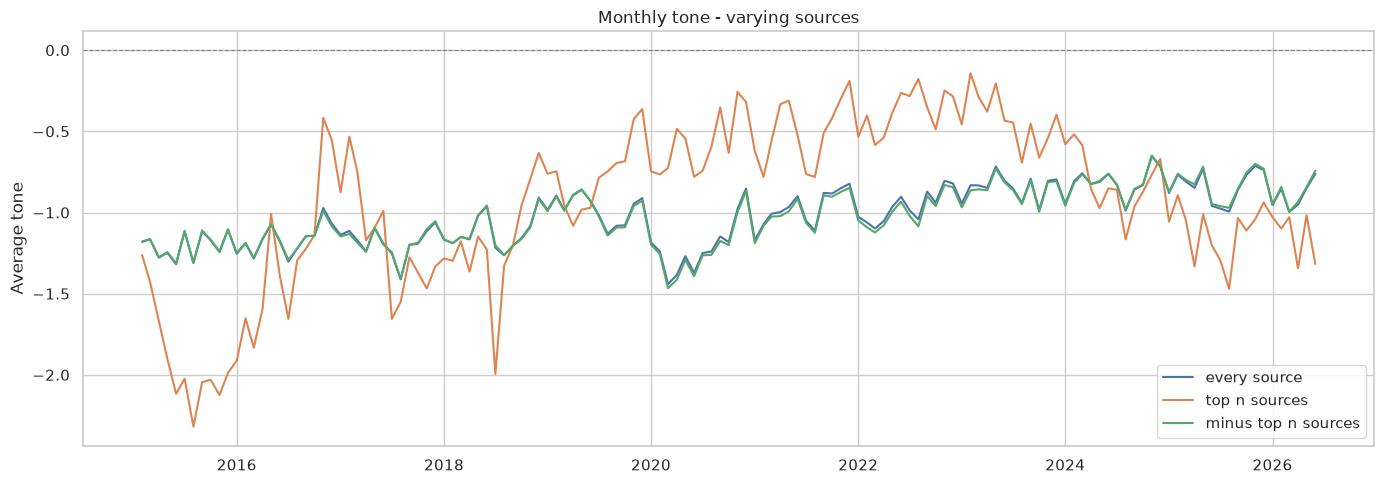

In [ ]:
tone_monthly = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_final
    GROUP BY month
    ORDER BY month
""").df()

tone_monthly_top_n = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS nb
    FROM gkg_final g
    JOIN top_n_sources_sample t
        ON g.SourceCommonName_ID = t.Source_ID
    GROUP BY month
    ORDER BY month
""").df()

tone_monthly_minus_top_n = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS nb
    FROM gkg_final g
    JOIN minus_top_n_sources_sample t
        ON g.SourceCommonName_ID = t.Source_ID
    GROUP BY month
    ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tone_monthly["month"], tone_monthly["avg_tone"], label="every source")
ax.plot(tone_monthly_top_n["month"], tone_monthly_top_n["avg_tone"], label="top n sources")
ax.plot(tone_monthly_minus_top_n["month"], tone_monthly_minus_top_n["avg_tone"], label="minus top n sources")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Monthly tone - varying sources")
ax.set_ylabel("Average tone")
ax.legend()
plt.tight_layout()
plt.show()

Since the "all sources" and "minus top n sources" curves are almost superimposed, the main sources don't bias the results.

Let's test the correlation between the "all sources" and 'top n sources" curves.

In [ ]:
df = tone_monthly.merge(
    tone_monthly_top_n,
    on="month",
    suffixes=("_all", "_top")
)
df.head()

r = df["avg_tone_all"].corr(df["avg_tone_top"])

print(f"Corrélation de Pearson : {r:.3f}")

r, p = pearsonr(df["avg_tone_all"], df["avg_tone_top"])

print(f"r = {r:.3f}")
print(f"p-value = {p:.4g}")

Corrélation de Pearson : 0.478
r = 0.478
p-value = 3.521e-09


=> no correlation

## Conclusion
The main sources don't bias the results. We therefore don't have to clean the database in that sense.